<img src="images/banner.png" style="width: 100%;">

# Using Web APIs with Python

In [1]:
# conda install python-dotenv -y # we need to install python-dotenv to read .env files then set them as environment variables

References:

[1] Mitchell, Ryan. *Web scraping with python.* " O'Reilly Media, Inc.", 2024.

[2] Chapagain, Anish. *Hands-On Web Scraping with Python: Extract quality data from the web using effective Python techniques.* Packt Publishing Ltd, 2023.

[3] Elridge, Taryn. *Web automation and scraping with Python: Hands-on mastery of selenium, beautifulsoup, and real-world data extraction.* 2025.

[4] Requests Documentation - https://requests.readthedocs.io/en/latest/user/quickstart/

[5] Revised and grammar checked using ChatGPT - https://chatgpt.com/

Prepared by: Leodegario Lorenzo II

In this notebook, we will demonstrate how to use and integrate APIs into our code. Specifically, we will use the `requests` library to send HTTP requests to several APIs, retrieve their responses, and process the returned data for further use.

In essence, an **Application Programming Interface (API)** is a standardized interface that allows one software application to communicate with another. APIs enable systems to exchange data and functionality, even if they are built using different programming languages or architectures.

In particular, we will focus on **Web APIs**, which allow us to access data from remote servers over the internet. These APIs are commonly used to retrieve structured data that can then be analyzed, transformed, or stored within our own applications.

We will cover:

1. **API prerequisites** — including understanding documentation and securing access credentials (e.g., API keys).

2. **Sending API requests** using the requests library.

3. **Processing API responses** — parsing the returned data (typically `JSON`) and storing it for further analysis.

In [38]:
import json
from time import sleep

import requests
import pandas as pd

## 1 IP Geolocation

The first API that we will use in this notebook is the **[IP Geolocation API](https://ip-api.com/)** which is a free for non-commercial use, no key required API, that translates an input IP address to a physical address. The documentation for this API can be found at:

https://ip-api.com/docs

Specifically we will use the `JSON` endpoint for this API.

```
http://ip-api.com/json/{query}
```

With optional parameters

| Parameter | Description |
| :--- | :--- |
| **fields** | response fields *optional* |
| **lang** | response language *optional* |
| **callback** | wrap inside (JSONP) *optional* |

We also note that the *Usage limit* for this API is **45 requests per minute** from an IP address.

Let's demonstrate how we perform calls to this API using request. First, we form the path according to our desired query. For this example, let's say we want to find the address of a friend with an IP address of `61.9.109.182`.

In [3]:
query = '61.9.109.182'
base_url = f'http://ip-api.com/json/{query}'

response = requests.get(base_url)
response

<Response [200]>

If the request was successfull and the response is OK (`200`), we can digest the result using the `.json()` method of the `Response` object.

In [4]:
response.json()

{'status': 'success',
 'country': 'Philippines',
 'countryCode': 'PH',
 'region': '00',
 'regionName': 'Metro Manila',
 'city': 'Quezon City',
 'zip': '1114',
 'lat': 14.6538,
 'lon': 121.0634,
 'timezone': 'Asia/Manila',
 'isp': 'Sky Cable Corporation',
 'org': 'Sky Cable Corporation',
 'as': 'AS17970 SKYBroadband SKYCable Corporation',
 'query': '61.9.109.182'}

Let's say we want to integrate this API with a program that calculates the distance between the address of a given ip address with a particular location. Firstly, we might want to limit the output to only include the `status`, `message` (if the request fails), and the `lat` and `lon` coordinates.

In [5]:
def get_lat_lon(ip_address):
    base_url = f'http://ip-api.com/json/{ip_address}'
    params = {'fields': 'status,message,lat,lon'}

    try:
        response = requests.get(base_url, params=params)
        data = response.json()
        response.raise_for_status()
        if data['status'] == 'fail':
            raise requests.RequestException(data['message'])
    except requests.RequestException as e:
        print("Failed request: ", e)
        return None, None
    else:
        return data['lat'], data['lon']

In [6]:
from utils import haversine

In [7]:
# Known location - Kilometer 0 (Rizal Park)
lat = 14.5826446
lon = 120.9761138

# Get lat and lon coordinates of input IP address
ip_address = '61.9.109.182'
ip_lat, ip_lon = get_lat_lon(ip_address)

# Calculate the distance between the two points
distance = haversine(lat, lon, ip_lat, ip_lon)

print(f"The distance of the query to Rizal park is {distance:.2f} km.")

The distance of the query to Rizal park is 12.28 km.


## 2 OpenWeather

The next API that we'll be using is the **OpenWeatherMap** API. Which can be used to fetch historical weather data for a given coordinates. It requires a free API key from https://openweathermap.org/

To use this API,

1. **Get an API Key**: Sign up at [OpenWeatherMap](https://openweathermap.org/) to get your API key. Verify your email address.
2. **Add your API Key to the environment variables**: Place your API Key onto an `.env` file using the environment variable `OPENWEATHER_API_KEY`.
3. **Check the documentation**: The documentation of the API that we'll be using can be found at [OpenWeather Curent Forecast API Docs](https://openweathermap.org/current?collection=current_forecast)
4. **Check the rate limits**: For a free plan, the rate limit is `60` calls per minute and `1,000,000` calls per month.  See [Subscriptions](https://home.openweathermap.org/subscriptions) and [Pricing](https://openweathermap.org/price) for more details.

To load our environment variables, we use the `dotenv` library.

In [8]:
import os

from dotenv import load_dotenv


# Load environment variables in the `.env` file found in this folder
load_dotenv();

### Geocoding API

Say we want to use the **OpenWeather API** to get the current weather for the city of `Makati`. We need to first get the `lat` and `lon` of the city since this is the required parameter in the **Current Forecast API**. To do this, OpenWeatherMap provides a simple **Geocoding API** which we can use.

In [9]:
city_name = 'Makati City'
limit = 1
api_key = os.getenv('OPENWEATHER_API_KEY')

endpoint = 'http://api.openweathermap.org/geo/1.0/direct'
params = {'q': city_name, 'appid': api_key, 'limit': limit}

response = requests.get(endpoint, params=params)
response.status_code

200

Let's check the result of our API call:

In [10]:
result = response.json()
result

[{'name': 'Makati',
  'local_names': {'ru': 'Макати',
   'es': 'Macati',
   'ja': 'マカティ',
   'ks': 'مکاتی',
   'tl': 'Makati',
   'ur': 'مکاتی',
   'fa': 'ماکاتی',
   'en': 'Makati',
   'ar': 'ماكاتي'},
  'lat': 14.5567949,
  'lon': 121.0211226,
  'country': 'PH'}]

We can then use the result for our succeeding API calls, when we try to determine the weather in the city of Makati.

In [11]:
lat, lon = result[0]['lat'], result[0]['lon']

### Current Weather Data

Let's now use the **[Current Weather Data API](https://openweathermap.org/current?collection=current_forecast)** to access the current weather data for any given location. As an example, let's use Makati City as the location of interest for our query.

In [12]:
units = 'metric'

endpoint = 'https://api.openweathermap.org/data/2.5/weather'
params = {'lat': lat, 'lon': lon, 'appid': api_key, 'units': units}

response = requests.get(endpoint, params)
response.status_code

200

In [13]:
result = response.json()
result

{'coord': {'lon': 121.0211, 'lat': 14.5568},
 'weather': [{'id': 801,
   'main': 'Clouds',
   'description': 'few clouds',
   'icon': '02n'}],
 'base': 'stations',
 'main': {'temp': 28.65,
  'feels_like': 31.49,
  'temp_min': 27.6,
  'temp_max': 29.86,
  'pressure': 1011,
  'humidity': 67,
  'sea_level': 1011,
  'grnd_level': 1010},
 'visibility': 10000,
 'wind': {'speed': 4.63, 'deg': 130},
 'clouds': {'all': 20},
 'dt': 1772536391,
 'sys': {'type': 1,
  'id': 8160,
  'country': 'PH',
  'sunrise': 1772489518,
  'sunset': 1772532258},
 'timezone': 28800,
 'id': 7091184,
 'name': 'Valenzuela',
 'cod': 200}

### 5 Day Weather Forecast

We also demonstrate the use of 5-day with data every 3 hours weather forecast API. See **[5 Day Weather Forecast API](https://openweathermap.org/forecast5?collection=current_forecast)** for documentation.

In [14]:
units = 'metric'

endpoint = 'https://api.openweathermap.org/data/2.5/forecast'
params = {'lat': lat, 'lon': lon, 'appid': api_key, 'units': units}

response = requests.get(endpoint, params)
response.status_code

200

In [15]:
result = response.json()
result

{'cod': '200',
 'message': 0,
 'cnt': 40,
 'list': [{'dt': 1772539200,
   'main': {'temp': 28.49,
    'feels_like': 31.18,
    'temp_min': 28.4,
    'temp_max': 28.49,
    'pressure': 1011,
    'sea_level': 1011,
    'grnd_level': 1011,
    'humidity': 67,
    'temp_kf': 0.09},
   'weather': [{'id': 801,
     'main': 'Clouds',
     'description': 'few clouds',
     'icon': '02n'}],
   'clouds': {'all': 20},
   'wind': {'speed': 5.74, 'deg': 139, 'gust': 6.37},
   'visibility': 10000,
   'pop': 0,
   'sys': {'pod': 'n'},
   'dt_txt': '2026-03-03 12:00:00'},
  {'dt': 1772550000,
   'main': {'temp': 27.89,
    'feels_like': 30.33,
    'temp_min': 26.68,
    'temp_max': 27.89,
    'pressure': 1011,
    'sea_level': 1011,
    'grnd_level': 1013,
    'humidity': 69,
    'temp_kf': 1.21},
   'weather': [{'id': 801,
     'main': 'Clouds',
     'description': 'few clouds',
     'icon': '02n'}],
   'clouds': {'all': 21},
   'wind': {'speed': 4.69, 'deg': 101, 'gust': 4.89},
   'visibility': 1000

Let's place the result onto a `pandas` `DataFrame` for easier inspection and further analysis.

In [16]:
weather_forecast = pd.json_normalize(result['list'])
weather_forecast.dt_txt = pd.to_datetime(weather_forecast.dt_txt)
weather_forecast.loc[:, 'date_time'] = weather_forecast.dt_txt.dt.strftime('%a %d-%b %I %p')
weather_forecast.dtypes

dt                          int64
weather                    object
visibility                  int64
pop                       float64
dt_txt             datetime64[ns]
main.temp                 float64
main.feels_like           float64
main.temp_min             float64
main.temp_max             float64
main.pressure               int64
main.sea_level              int64
main.grnd_level             int64
main.humidity               int64
main.temp_kf              float64
clouds.all                  int64
wind.speed                float64
wind.deg                    int64
wind.gust                 float64
sys.pod                    object
rain.3h                   float64
date_time                  object
dtype: object

In [17]:
import matplotlib.pyplot as plt

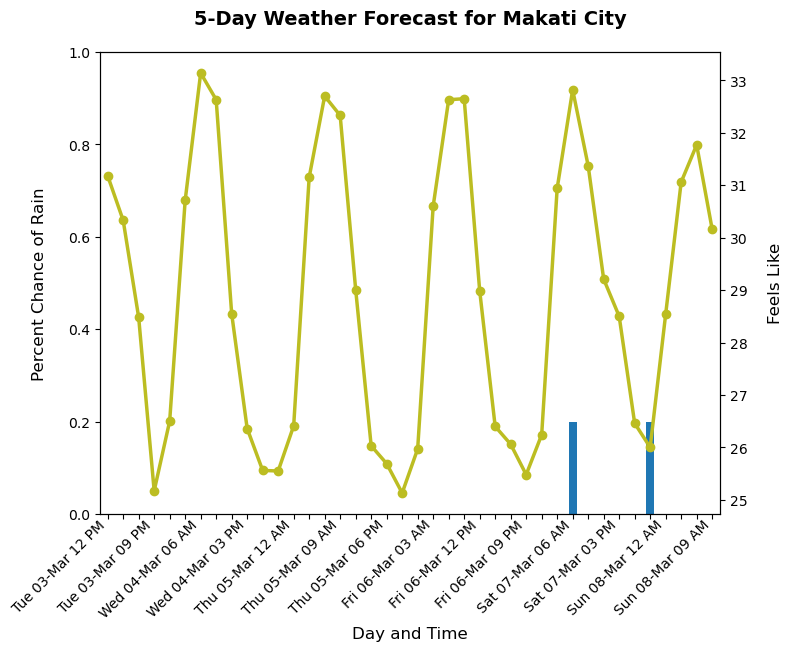

In [18]:
fig, ax = plt.subplots(figsize=(8, 6))

ax2 = ax.twinx()

# Plot the chance of rain and feels like (temp)
weather_forecast.plot(kind='bar', x='date_time', y='pop', ax=ax, legend=False)
weather_forecast.plot(kind='line', x='date_time', y='main.feels_like', ax=ax2,
                      style='o-', lw=2.5, legend=False, color='tab:olive');

# Set xlim for proper context
ax.set_ylim(0, 1.)

# Reduce number of xticks for cleaner plot
xtick_labels = [text if not i % 3 else None for i, text in enumerate(ax.get_xticklabels())]
ax.tick_params(axis='x', pad=-1)
ax.set_xticklabels(xtick_labels, ha='right', rotation=45)

# Add axes labels
ax.set_ylabel("Percent Chance of Rain", fontsize=12, labelpad=15)
ax2.set_ylabel("Feels Like", fontsize=12, labelpad=15)
ax.set_xlabel("Day and Time", fontsize=12)
ax.set_title("5-Day Weather Forecast for Makati City", fontsize=14,
             weight='bold', pad=20);

## 3 Google API

One of the most extensive collections of Web APIs available today is offered by Google. The **Google API**s ecosystem provides access to a wide range of services, including mapping tools, cloud computing resources, machine learning models, productivity applications, and more.

In this final section, we will demonstrate how to authenticate and interact with a Google API, and explore how these services can be integrated into our own Python programs to retrieve data or leverage advanced functionalities.

### Places API

To access Google APIs, we must first generate an API key for the specific service we intend to use. Each Google API requires proper authentication to ensure secure and authorized access.

For this demonstration, we will use the **Places API**. To generate an API key, navigate to the official documentation page for the Places API and click the **“Get Started”** button. This will guide you through the process of creating or selecting a Google Cloud project, enabling the API, and generating your API credentials.

Once you've acquired your API key, place them in the environment file `.env` with the name `PLACES_API_KEY`.

Do also note the billings and pricing of the usage of Places API found in [Google Maps Pricing](https://developers.google.com/maps/billing-and-pricing/pricing).

![Places API Billing](images/places_api_billing.PNG)

Places API allows for unlimited free usage for both **Places API Text Search Essentials (IDs Only)** and **Places API Place Details Essentials (IDs Only)**. Meanwhile, it has a usage cap of `10,000` calls per month for the other services.

#### Text Search

Let's demonstrate how we can use the **Text Search** functionality of the Places API. For more details on its usage, please see the [Text Search (New) Documentation](https://developers.google.com/maps/documentation/places/web-service/text-search).

You'll notice that the required request for this is a `POST` request, as such, we will revise our request format accordingly.

As an example, let's look for `ramen restaurants` near Makati.

In [62]:
endpoint = 'https://places.googleapis.com/v1/places:searchText'
data = {'textQuery': 'ramen restaurants',
        'locationBias': {
            'circle': {
                'center': {'latitude': lat, 'longitude': lon}, # Makati City
                'radius': 2_000 # in meters
            }
        }}
headers = {'Content-Type': 'application/json',
           'X-Goog-Api-Key': os.getenv('PLACES_API_KEY'),
           'X-Goog-FieldMask': 'places.attributions,places.id,places.name,nextPageToken,places.movedPlace,places.movedPlaceId'}

result = requests.post(endpoint, data=json.dumps(data), headers=headers)
result

<Response [200]>

In [63]:
result.json()

{'places': [{'name': 'places/ChIJF4IyqwfJlzMRTJYETLuK4dg',
   'id': 'ChIJF4IyqwfJlzMRTJYETLuK4dg'},
  {'name': 'places/ChIJR0l6ZwDJlzMR2flT_4VM61A',
   'id': 'ChIJR0l6ZwDJlzMR2flT_4VM61A'},
  {'name': 'places/ChIJlZgnmjbJlzMRd_s9XovL-uE',
   'id': 'ChIJlZgnmjbJlzMRd_s9XovL-uE'},
  {'name': 'places/ChIJ2Sa3iWLJlzMRWtcUEm9rfKs',
   'id': 'ChIJ2Sa3iWLJlzMRWtcUEm9rfKs'},
  {'name': 'places/ChIJtbcuexLJlzMRmzn8_XT8DPU',
   'id': 'ChIJtbcuexLJlzMRmzn8_XT8DPU'},
  {'name': 'places/ChIJPXAEYgDJlzMRCRiQxOHAnTE',
   'id': 'ChIJPXAEYgDJlzMRCRiQxOHAnTE'},
  {'name': 'places/ChIJ742WIAnJlzMRJ2Zukrqv4Ig',
   'id': 'ChIJ742WIAnJlzMRJ2Zukrqv4Ig'},
  {'name': 'places/ChIJWWQFP1rJlzMRcAC2yoPJRQs',
   'id': 'ChIJWWQFP1rJlzMRcAC2yoPJRQs'},
  {'name': 'places/ChIJN6xK2WvJlzMRQdKhEHTSxT0',
   'id': 'ChIJN6xK2WvJlzMRQdKhEHTSxT0'},
  {'name': 'places/ChIJIYckMqjJlzMRE1Sklc_IvLs',
   'id': 'ChIJIYckMqjJlzMRE1Sklc_IvLs'},
  {'name': 'places/ChIJqw8iAWTJlzMRig4qjv5P2EI',
   'id': 'ChIJqw8iAWTJlzMRig4qjv5P2EI'},


Notice that we have retrieve `20` places as a result of our text query. There's also a `nextPageToken` which we can use to get the next page of the text search result. Let's store our search result on appropriately named variables.

In [64]:
ramen_places = result.json()['places']
next_page_token = result.json()['nextPageToken']

Let's retrieve the results on the next pages programatically.

In [65]:
endpoint = 'https://places.googleapis.com/v1/places:searchText'

for i in range(5):
    try:
        # Data Query and Headers
        data = {'textQuery': 'ramen restaurants',
                'locationBias': {
                    'circle': {
                        'center': {'latitude': lat, 'longitude': lon}, # Makati City
                        'radius': 2_000 # in meters
                    }},
                'pageToken': next_page_token
               }
        headers = {'Content-Type': 'application/json',
                   'X-Goog-Api-Key': os.getenv('PLACES_API_KEY'),
                   'X-Goog-FieldMask': 'places.attributions,places.id,places.name,nextPageToken,places.movedPlace,places.movedPlaceId'}

        # POST request
        result = requests.post(endpoint, data=json.dumps(data), headers=headers)

        # Try to append the result
        ramen_places.extend(result.json()['places'])
        next_page_token = result.json()['nextPageToken']

    except KeyError as e:
        print("Key not found: ", e)
        break
    else:
        print('Page: ', i + 2, 'Status Code: ', result.status_code)
        sleep(1)

Page:  2 Status Code:  200
Key not found:  'nextPageToken'


In [69]:
ramen_places = pd.DataFrame(ramen_places).drop_duplicates()

In [70]:
len(ramen_places)

60

In total, we gathered `60` ramen places from our query.

#### Place Details

Gathering the place `id` of a given text query is not very useful, as such, we proceed to gather further data about the details of our query using the **Place Details** functionality of the Places API. For this demonstration, we'll be triggering a ***Place Details Enterprise SKU***, which has a free usage of up to `1,000` calls each month. See screenshot below for more details:

![Places API Enterprise](images/places_api_enterprise.PNG)

For this demonstration, we'll get the details for each of the `ramen places` we gathered from our previous text search query. We test it on the first place we've found from our text search.

In [71]:
ramen_places.iloc[0].id

'ChIJF4IyqwfJlzMRTJYETLuK4dg'

In [72]:
endpoint = f'https://places.googleapis.com/v1/places/{ramen_places.iloc[0].id}'
fields = ['attributions', 'id', 'moved_place', 'moved_place_id', 'displayName',
          'photos', 'addressComponents', 'adrFormatAddress',
          'formattedAddress', 'location', 'plusCode', 'postalAddress',
          'shortFormattedAddress', 'types', 'viewport', 'currentOpeningHours',
          'currentSecondaryOpeningHours', 'nationalPhoneNumber',
          'internationalPhoneNumber', 'priceLevel', 'priceRange', 'rating',
          'regularOpeningHours', 'regularSecondaryOpeningHours',
          'userRatingCount', 'websiteUri']
headers = {'X-Goog-Api-Key': os.getenv('PLACES_API_KEY'),
           'X-Goog-FieldMask': ','.join(fields),
           'Content-Type': 'application/json'}

result = requests.get(endpoint, headers=headers)
result.status_code

200

Let's store the result in a variable accordingly.

In [75]:
ramen_places_details = [result.json()]

In [80]:
with open('outputs/ramen_places.jsonl', 'a') as f:
    f.write(json.dumps(ramen_places_details[0]) + '\n')

Let's proceed to collect the place details of all the other places in our search result.

In [81]:
base_url = 'https://places.googleapis.com/v1/places/'
fields = ['attributions', 'id', 'moved_place', 'moved_place_id', 'displayName',
          'photos', 'addressComponents', 'adrFormatAddress',
          'formattedAddress', 'location', 'plusCode', 'postalAddress',
          'shortFormattedAddress', 'types', 'viewport', 'currentOpeningHours',
          'currentSecondaryOpeningHours', 'nationalPhoneNumber',
          'internationalPhoneNumber', 'priceLevel', 'priceRange', 'rating',
          'regularOpeningHours', 'regularSecondaryOpeningHours',
          'userRatingCount', 'websiteUri']
headers = {'X-Goog-Api-Key': os.getenv('PLACES_API_KEY'),
           'X-Goog-FieldMask': ','.join(fields),
           'Content-Type': 'application/json'}

for i, ramen_place in ramen_places.iloc[1:].iterrows():
    endpoint = f'{base_url}{ramen_place.id}'

    try:
        response = requests.get(endpoint, headers=headers)
        sleep(0.5)
        response.raise_for_status()
    except requests.RequestException as e:
        print(f"Failed request for {ramen_place.id}: ", e)
    else:
        print(f"Request success for {ramen_place.id}")
        ramen_places_details.append(response.json())
        with open('outputs/ramen_places.jsonl', 'a') as f:
            f.write(json.dumps(ramen_places_details[-1]) + '\n')

Request success for ChIJR0l6ZwDJlzMR2flT_4VM61A
Request success for ChIJlZgnmjbJlzMRd_s9XovL-uE
Request success for ChIJ2Sa3iWLJlzMRWtcUEm9rfKs
Request success for ChIJtbcuexLJlzMRmzn8_XT8DPU
Request success for ChIJPXAEYgDJlzMRCRiQxOHAnTE
Request success for ChIJ742WIAnJlzMRJ2Zukrqv4Ig
Request success for ChIJWWQFP1rJlzMRcAC2yoPJRQs
Request success for ChIJN6xK2WvJlzMRQdKhEHTSxT0
Request success for ChIJIYckMqjJlzMRE1Sklc_IvLs
Request success for ChIJqw8iAWTJlzMRig4qjv5P2EI
Request success for ChIJ69YAWwDJlzMRFFT5x2sKXS8
Request success for ChIJiUOuZgDJlzMRK4VK1TwySHE
Request success for ChIJ-UovMADJlzMRuu2pW2-jA88
Request success for ChIJGRjOWQDJlzMRbqvkfX9_l78
Request success for ChIJ-cyvawDJlzMR3IsLioMogtc
Request success for ChIJPwRaEgDJlzMRzrAbrsyOrCg
Request success for ChIJT1WvnA_JlzMR6dlIhWZbPy4
Request success for ChIJZQz9ajvJlzMRWs3jE-ZBvZc
Request success for ChIJpZQkc_LJlzMRBUUfiSJjnqE
Request success for ChIJVXV_TwzJlzMRFhdeS8Ncygk
Request success for ChIJ4x5qO-nJlzMR4aFf

Let's digest the result into a `pandas` `DataFrame` for succeeding analysis. 

In [85]:
ramen_places_df = []
for ramen_place_detail in ramen_places_details:
    ramen_places_df.append({
        'name': ramen_place_detail.get('displayName', {'text': None})['text'],
        'address': ramen_place_detail.get('formattedAddress', None),
        'phone_number': ramen_place_detail.get('internationalPhoneNumber', None),
        'rating': ramen_place_detail.get('rating', None),
        'rating_count': ramen_place_detail.get('userRatingCount', None),
        'price_range_start': ramen_place_detail.get('priceRange', {'startPrice': {'units': None}})['startPrice']['units'],
        'price_range_end': ramen_place_detail.get('priceRange', {'endPrice': {'units': None}})['endPrice']['units']
    })
ramen_places_df = pd.DataFrame(ramen_places_df)

Now that we have the details of all of the ramen places near Makati, let's find out which place would be a good place to eat ramen. Let's sort the result according to highest `rating`, `rating_count`, and decreasing `price_range_start`. Let's also filter the restaurants which has `rating_count` less than `100`.

In [89]:
ramen_places_df[ramen_places_df.rating_count >= 100].sort_values(
    by=['rating', 'rating_count', 'price_range_start'],
    ascending=[False, False, True]).head(10)

,name,address,phone_number,rating,rating_count,price_range_start,price_range_end
43,Menya Kokoro Ramen Izakaya Uptown Mall,"9th Ave, Taguig, Metro Manila, Philippines",+63 2 7758 6493,4.8,2131,500,1000
21,Ramen Ron Rockwell,"GF, RS-103, Edades Tower Rockwell Center Makat...",+63 917 628 7245,4.8,1722,500,1000
32,Ramen Ron BGC,"Ground Floor, Bonifacio High Street - Central ...",+63 917 136 1991,4.8,1640,500,1000
58,Tsukemen,"GXMJ+XP7, Seaside Blvd, 123, Pasay City, 1300 ...",None,4.8,936,1,500
23,Gatsu-man,"9th Ave, Taguig, Metro Manila, Philippines",None,4.8,916,1,500
47,Hanamaruken Ramen,"Santolan Town Plaza, Col. ボニー・セラーノ・アベニュー San J...",None,4.8,765,500,1000
12,Fujiyama 55 Ramen Philippines,"Building 6, EDSA, corner, 1100 McKinley Rd, Ma...",None,4.8,462,500,1000
9,"Ramen Ibuki, Uptown BGC","Uptown Parade, 9th Ave, Bonifacio Global City,...",+63 917 191 3888,4.8,381,500,1000
52,Tonkotsu Kazan Ramen SM Mall of Asia,"Level 1, North Entertainment Mall, SM Mall of ...",None,4.8,173,1,500
27,Musashi-Tei Japanese Restaurant,"Level 3, Al Fresco, One Ayala, 1 Ayala Ave, Ma...",+63 956 045 1678,4.7,180,500,1000


<img src="images/banner-down.png" style="width: 100%;">